# **Compare models performance 📊**

## **Definitions**

- true positives (TP) = number of entities of the ground truth found by the model
- false positives (FP) = number of entities not in the ground truth found by the model
- false negatives (FN) = number of entities of the ground truth not found by the model

$$
{\rm precision} = \frac{TP}{TP + FP}
$$

$$
{\rm recall} = \frac{TP}{TP + FN}
$$

$$
F_1 = 2 \frac{ {\rm precision} \times {\rm recall} }{ {\rm precision}+{\rm recall} } = \frac{ 2 TP }{ 2TP + FP + FN }
$$


$$
F_{\beta} = \frac{ (1 + \beta^2) \times {\rm precision} \times {\rm recall} }{ (\beta^2 \times {\rm precision}) + {\rm recall} } = \frac{ (1 + \beta^2) \times TP }{ \beta^2 \times (TP + FN) + TP + FP }
$$

In the case of Named Entity Recognition, we focus more on precision than recall. We want the model to make no mistakes rather that identify all entities.

## **Setup**

In [133]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import pandas as pd

from mdner_llm.core.plot_evaluation_metrics import plot_llm_cost_vs_time, plot_score

pd.__version__

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'2.3.3'

## **Comparison of LLM Models**

In [134]:
# LLMs evaluation results
path = Path("../results/llm/evaluation_stats/grouped_evaluation_metrics.csv")
llm_df = pd.read_csv(path)
model_names = llm_df["model_name"].unique()
framework_names = llm_df["framework_name"].unique()
category_names = llm_df["category"].unique()
print(f"Models ({len(model_names)}): {', '.join(model_names)}")
print(f"Frameworks ({len(framework_names)}): {', '.join(framework_names)}")
print(f"Categories ({len(category_names)}): {', '.join(category_names)}")
llm_df

Models (12): anthropic/claude-sonnet-4.6, deepseek/deepseek-v3.2, google/gemini-3.1-pro-preview, google/gemma-4-31b-it, meta-llama/llama-4-maverick, minimax/minimax-m2.7, mistralai/mistral-large-2512, openai/gpt-4o, openai/gpt-5.4, openai/gpt-oss-120b, qwen/qwen3.5-122b-a10b, z-ai/glm-5.1
Frameworks (2): instructor, noframework
Categories (7): FFM, MOL, SOFTNAME, SOFTVERS, STIME, TEMP, OVERALL


,model_name,framework_name,category,nb_of_texts_with_label,nb_gt_entities,nb_predicted_entities,is_correct_output_format,hallucination_rate,true_positives,false_positives,false_negatives,average_input_tokens,average_output_tokens,total_cost_usd,total_inference_time_sec,precision_score,recall_score,f1_score,fbeta_0.5_score
0,anthropic/claude-sonnet-4.6,instructor,FFM,82,179,141,100.000000,0.000000,130,11,49,3771.928571,227.845238,NaN,NaN,0.921986,0.726257,0.812500,0.874832
1,anthropic/claude-sonnet-4.6,instructor,MOL,110,566,519,100.000000,0.000000,324,195,242,3768.339286,216.428571,NaN,NaN,0.624277,0.572438,0.597235,0.613172
2,anthropic/claude-sonnet-4.6,instructor,SOFTNAME,74,125,106,100.000000,0.000000,96,10,29,3782.697368,227.407895,NaN,NaN,0.905660,0.768000,0.831169,0.874317
3,anthropic/claude-sonnet-4.6,instructor,SOFTVERS,45,52,40,100.000000,0.000000,36,4,16,3802.702128,243.893617,NaN,NaN,0.900000,0.692308,0.782609,0.849057
4,anthropic/claude-sonnet-4.6,instructor,STIME,67,98,104,100.000000,0.000000,84,20,14,3797.318841,241.594203,NaN,NaN,0.807692,0.857143,0.831683,0.817121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,openai/gpt-oss-120b,noframework,OVERALL,113,1100,1097,100.000000,26.086957,310,787,790,2232.382609,1389.826087,0.103766,1044.615206,0.282589,0.281818,0.282203,0.282434
164,qwen/qwen3.5-122b-a10b,instructor,OVERALL,113,1100,1176,100.000000,6.086957,426,750,674,3578.208696,18061.086957,4.679596,18865.322254,0.362245,0.387273,0.374341,0.366988
165,qwen/qwen3.5-122b-a10b,noframework,OVERALL,113,1368,1377,97.163121,5.673759,582,795,786,2355.914894,10733.531915,3.692613,12806.777941,0.422658,0.425439,0.424044,0.423211
166,z-ai/glm-5.1,instructor,OVERALL,113,1100,1250,100.000000,3.478261,867,383,233,3338.460870,4890.191304,2.525204,15674.594512,0.693600,0.788182,0.737872,0.710656


In [135]:
# Define parameters for the plot
# Metric to plot ("precision_score", "recall_score", "f1_score", "fbeta_0.5_score")
metric = "precision_score"
# Models
models = [
    # "openai/gpt-4o",
    "anthropic/claude-sonnet-4.6",
    "z-ai/glm-5.1",
    "openai/gpt-5.4",
    # "deepseek/deepseek-v3.2",
    "google/gemma-4-31b-it",
    "meta-llama/llama-4-maverick",
    # "nvidia/nemotron-3-super-120b-a12b",
    # "mistralai/mistral-large-2512",
    # "minimax/minimax-m2.7",
    # "openai/gpt-oss-120b",
    "qwen/qwen3.5-122b-a10b",
    "google/gemini-3.1-pro-preview",
]

In [136]:
# Categories to plot in this order
categories = ["OVERALL", "MOL", "FFM", "SOFTNAME", "SOFTVERS", "TEMP", "STIME"]
# More focused categories
# categories = ["OVERALL", "MOL"]

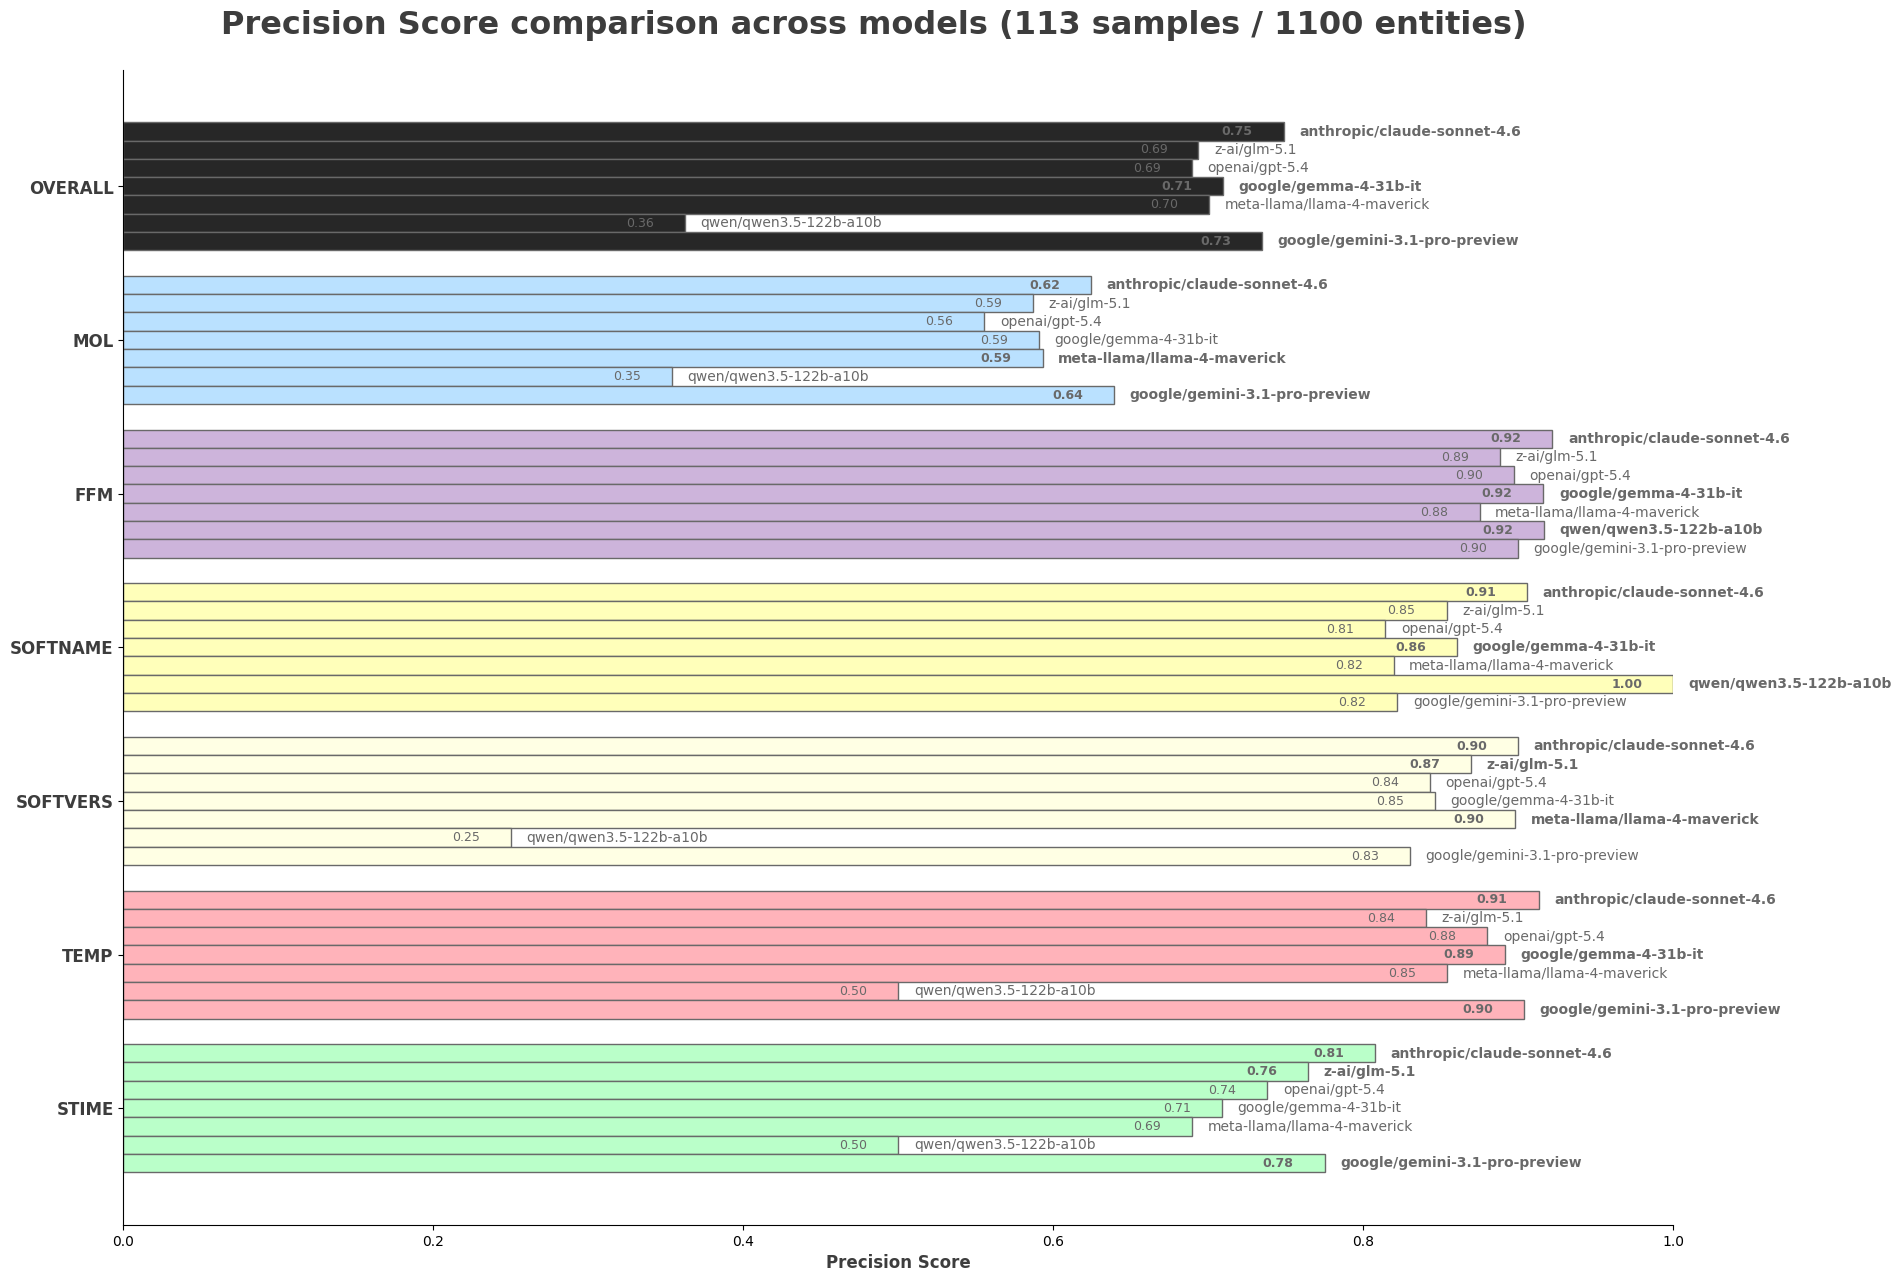

In [137]:
plot_score(
    df=llm_df,
    framework="instructor",
    metric=metric,
    categories=categories,
    models=models,
)

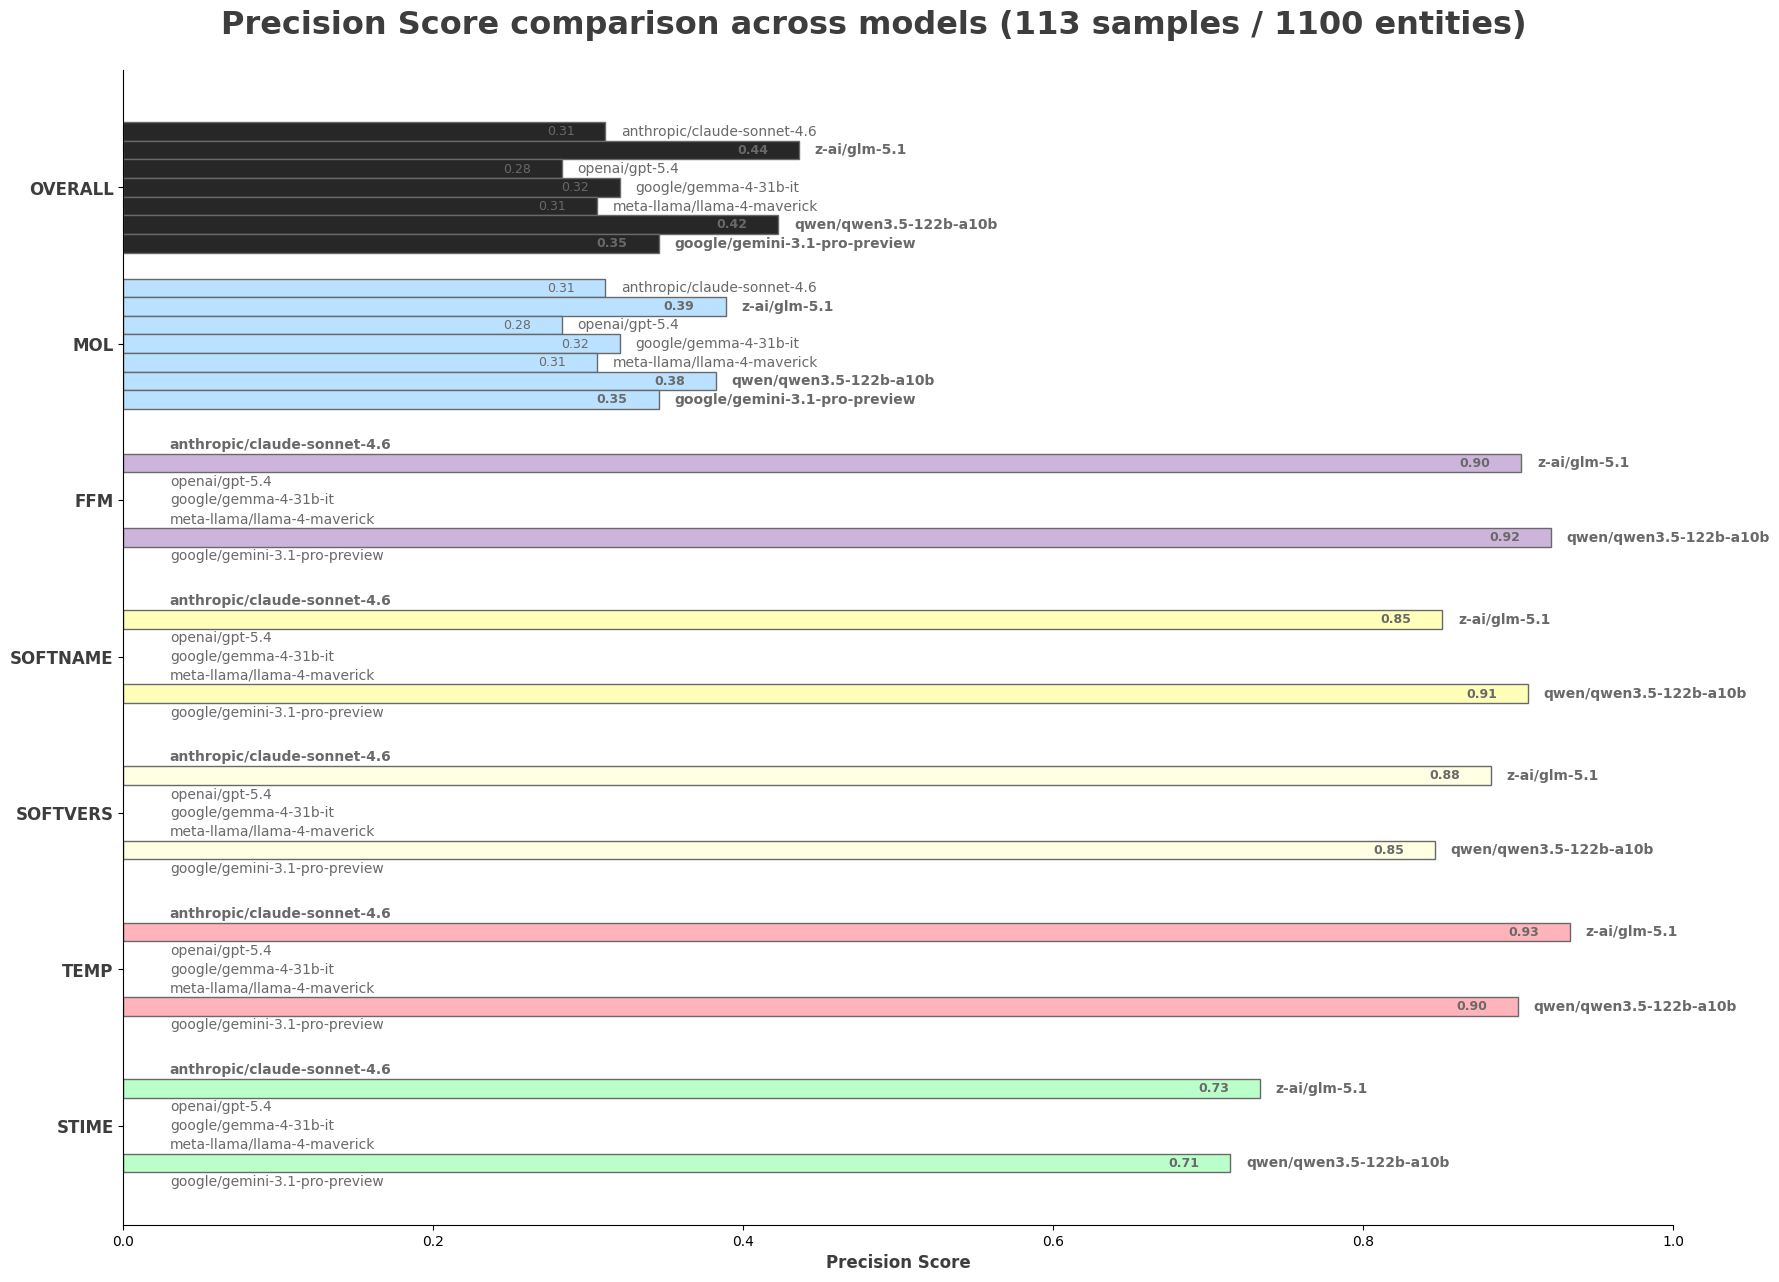

In [138]:
plot_score(
    df=llm_df,
    framework="noframework",
    metric=metric,
    categories=categories,
    models=models,
)


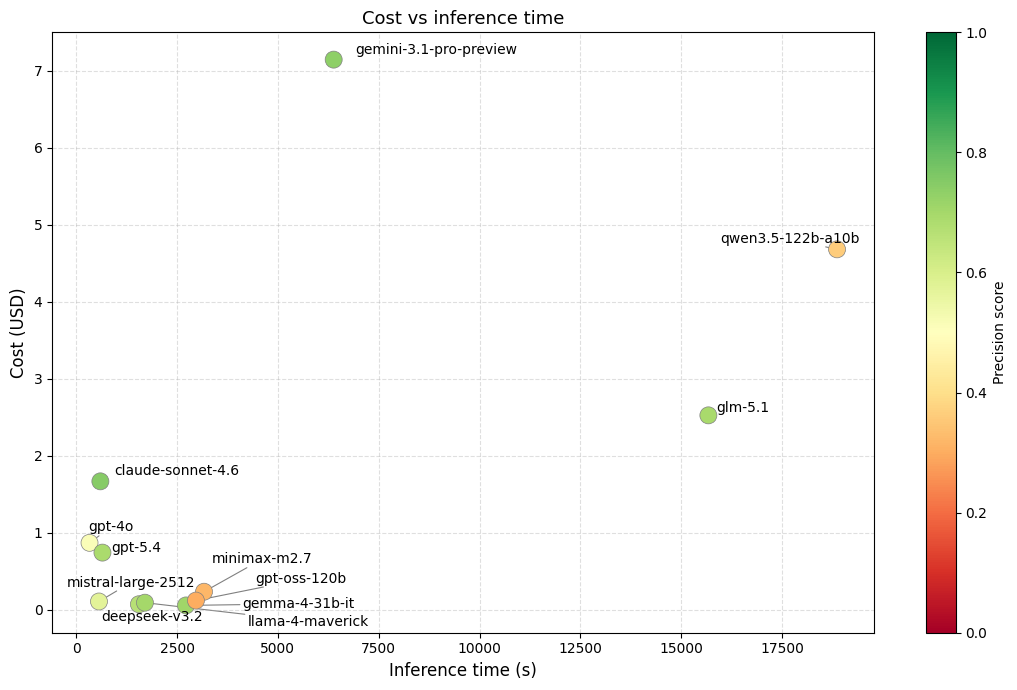

In [139]:
plot_llm_cost_vs_time(llm_df, framework="instructor")

## **Comparison of GLINER2 Models**

In [140]:
path = Path("../results/gliner/evaluation_stats/grouped_evaluation_metrics.csv")
gliner_df = pd.read_csv(path)
model_names = gliner_df["model_name"].unique()
category_names = gliner_df["category"].unique()
print(f"Models ({len(model_names)}): {', '.join(model_names)}")
print(f"Categories ({len(category_names)}): {', '.join(category_names)}")
gliner_df

Models (2): fastino/gliner2-base-v1, fastino/gliner2-large-v1
Categories (7): FFM, MOL, SOFTNAME, SOFTVERS, STIME, TEMP, OVERALL


,model_name,framework_name,category,nb_of_texts_with_label,nb_gt_entities,nb_predicted_entities,is_correct_output_format,hallucination_rate,true_positives,false_positives,false_negatives,average_input_tokens,average_output_tokens,total_cost_usd,total_inference_time_sec,precision_score,recall_score,f1_score,fbeta_0.5_score
0,fastino/gliner2-base-v1,noframework,FFM,19,46,33,100.0,0.0,23,10,23,239.315789,193.263158,NaN,NaN,0.696970,0.500000,0.582278,0.646067
1,fastino/gliner2-base-v1,noframework,MOL,20,96,63,100.0,0.0,43,20,53,241.150000,189.200000,NaN,NaN,0.682540,0.447917,0.540881,0.617816
2,fastino/gliner2-base-v1,noframework,SOFTNAME,19,29,31,100.0,0.0,13,18,16,231.894737,192.894737,NaN,NaN,0.419355,0.448276,0.433333,0.424837
3,fastino/gliner2-base-v1,noframework,SOFTVERS,11,14,14,100.0,0.0,4,10,10,220.909091,221.090909,NaN,NaN,0.285714,0.285714,0.285714,0.285714
4,fastino/gliner2-base-v1,noframework,STIME,16,22,27,100.0,0.0,20,7,2,252.812500,210.000000,NaN,NaN,0.740741,0.909091,0.816327,0.769231
5,fastino/gliner2-base-v1,noframework,TEMP,10,13,12,100.0,0.0,11,1,2,241.900000,225.200000,NaN,NaN,0.916667,0.846154,0.880000,0.901639
6,fastino/gliner2-large-v1,noframework,FFM,19,46,34,100.0,0.0,21,13,25,239.315789,206.789474,NaN,NaN,0.617647,0.456522,0.525000,0.576923
7,fastino/gliner2-large-v1,noframework,MOL,20,96,84,100.0,0.0,48,36,48,241.150000,198.600000,NaN,NaN,0.571429,0.500000,0.533333,0.555556
8,fastino/gliner2-large-v1,noframework,SOFTNAME,19,29,26,100.0,0.0,21,5,8,231.894737,204.210526,NaN,NaN,0.807692,0.724138,0.763636,0.789474
9,fastino/gliner2-large-v1,noframework,SOFTVERS,11,14,12,100.0,0.0,9,3,5,220.909091,228.181818,NaN,NaN,0.750000,0.642857,0.692308,0.725806


In [141]:
# Define parameters for the plot
# Metric to plot ("precision_score", "recall_score", "f1_score", "fbeta_0.5_score")
metric = "precision_score"
# Models
models = [
    "fastino/gliner2-base-v1",
    "fastino/gliner2-large-v1",
    # "fastino/gliner2-base-v1-finetuned",
    # "fastino/gliner2-large-v1-finetuned",
]

In [142]:
# Categories to plot in this order
categories = ["OVERALL", "MOL", "FFM", "SOFTNAME", "SOFTVERS", "TEMP", "STIME"]
# More focused categories
# categories = ["OVERALL", "MOL"]

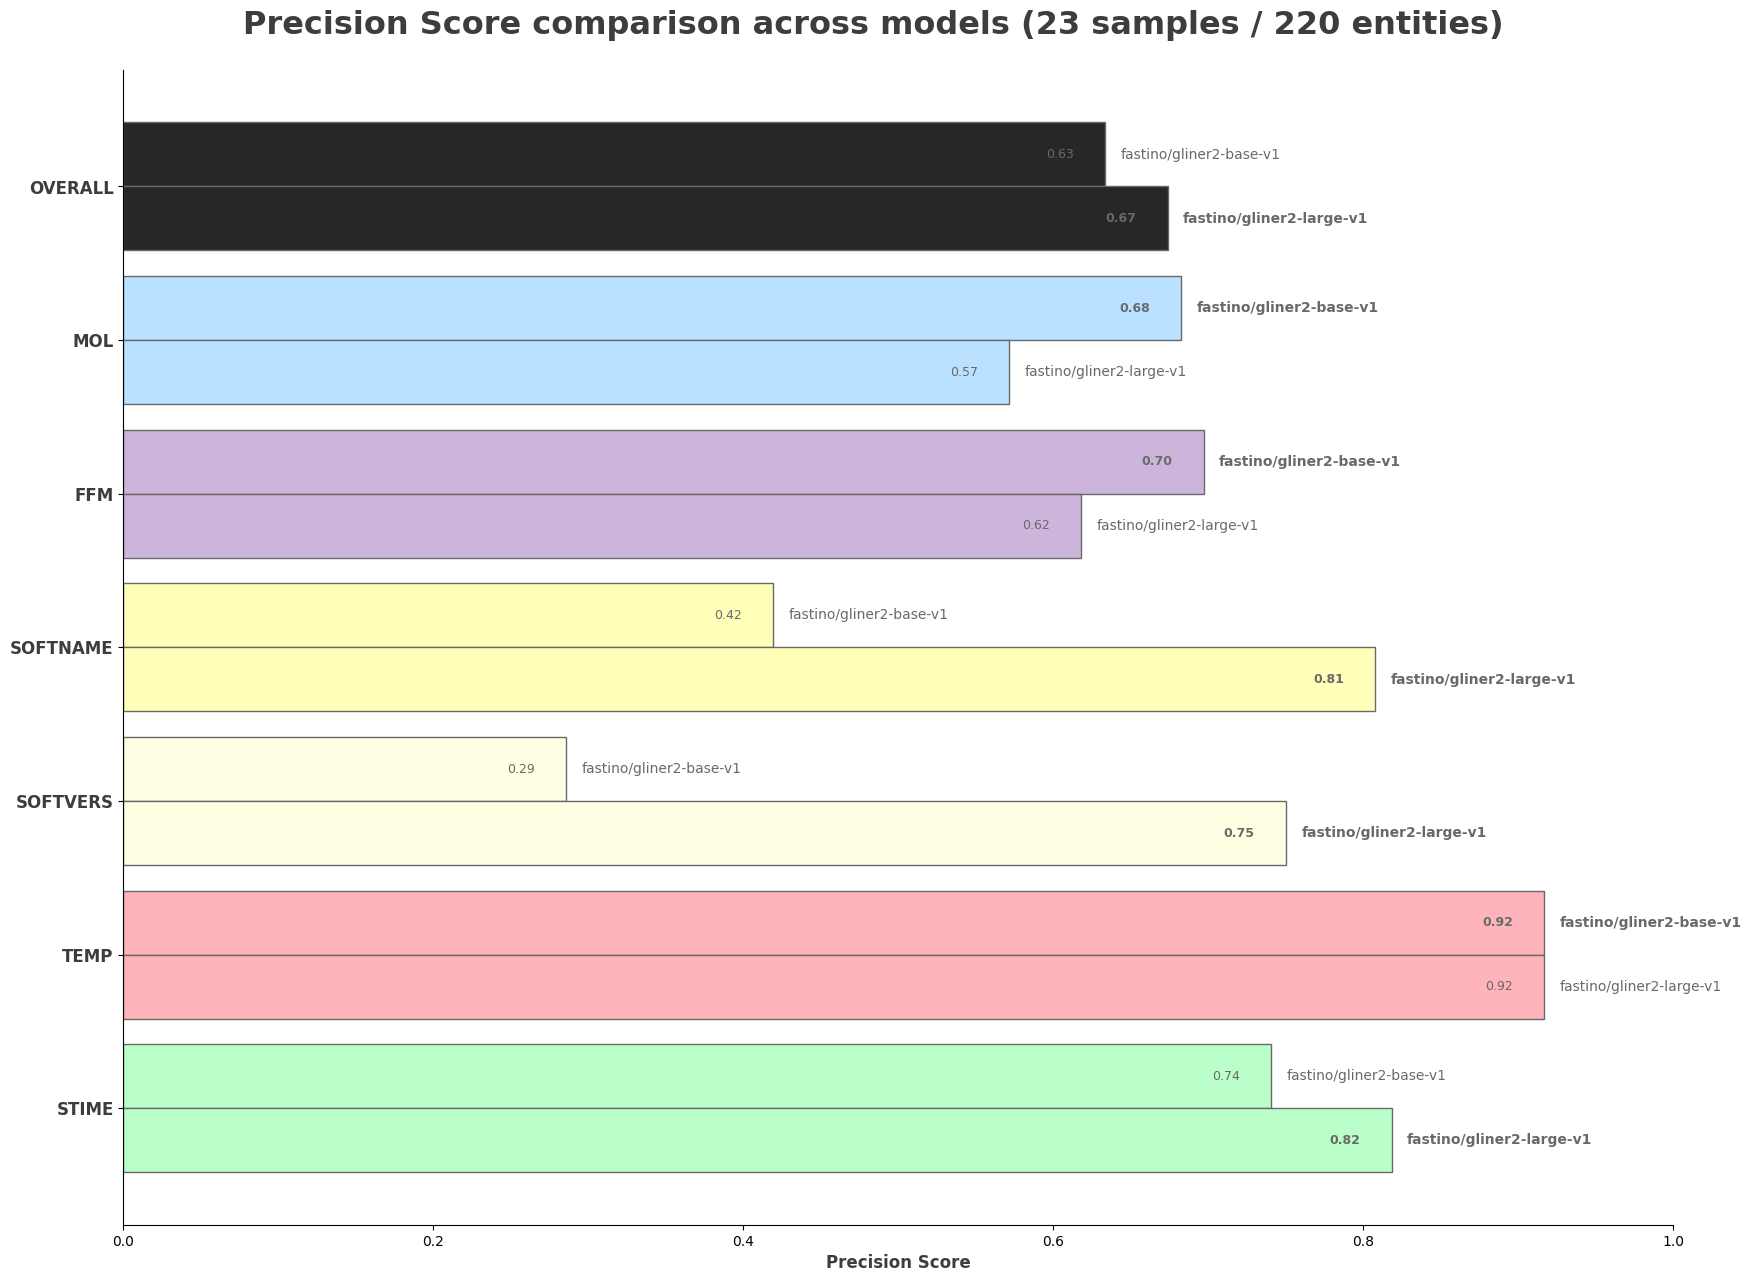

In [143]:
plot_score(
    df=gliner_df,
    framework="noframework",
    metric=metric,
    categories=categories,
    models=models,
    top_k=1,
)

## **Comparison of GLINER2 vs LLM Models**

In [144]:
# Concat all evaluation results
gliner_df["framework_name"] = None
eval_df = pd.concat([llm_df, gliner_df], ignore_index=True)
eval_df

,model_name,framework_name,category,nb_of_texts_with_label,nb_gt_entities,nb_predicted_entities,is_correct_output_format,hallucination_rate,true_positives,false_positives,false_negatives,average_input_tokens,average_output_tokens,total_cost_usd,total_inference_time_sec,precision_score,recall_score,f1_score,fbeta_0.5_score
0,anthropic/claude-sonnet-4.6,instructor,FFM,82,179,141,100.0,0.0,130,11,49,3771.928571,227.845238,NaN,NaN,0.921986,0.726257,0.812500,0.874832
1,anthropic/claude-sonnet-4.6,instructor,MOL,110,566,519,100.0,0.0,324,195,242,3768.339286,216.428571,NaN,NaN,0.624277,0.572438,0.597235,0.613172
2,anthropic/claude-sonnet-4.6,instructor,SOFTNAME,74,125,106,100.0,0.0,96,10,29,3782.697368,227.407895,NaN,NaN,0.905660,0.768000,0.831169,0.874317
3,anthropic/claude-sonnet-4.6,instructor,SOFTVERS,45,52,40,100.0,0.0,36,4,16,3802.702128,243.893617,NaN,NaN,0.900000,0.692308,0.782609,0.849057
4,anthropic/claude-sonnet-4.6,instructor,STIME,67,98,104,100.0,0.0,84,20,14,3797.318841,241.594203,NaN,NaN,0.807692,0.857143,0.831683,0.817121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,fastino/gliner2-large-v1,None,SOFTVERS,11,14,12,100.0,0.0,9,3,5,220.909091,228.181818,NaN,NaN,0.750000,0.642857,0.692308,0.725806
178,fastino/gliner2-large-v1,None,STIME,16,22,22,100.0,0.0,18,4,4,252.812500,217.000000,NaN,NaN,0.818182,0.818182,0.818182,0.818182
179,fastino/gliner2-large-v1,None,TEMP,10,13,12,100.0,0.0,11,1,2,241.900000,252.100000,NaN,NaN,0.916667,0.846154,0.880000,0.901639
180,fastino/gliner2-base-v1,None,OVERALL,23,220,180,100.0,0.0,114,66,106,235.695652,179.086957,0.0,10.797607,0.633333,0.518182,0.570000,0.606383


In [145]:
# Define parameters for the plot
# Framework for LLMs ("noframework", "instructor", "pydanticai")
framework = "instructor"
# Metric to plot ("precision_score", "recall_score", "f1_score", "fbeta_0.5_score")
metric = "precision_score"
# Models
models = [
    # "openai/gpt-4o",
    "anthropic/claude-sonnet-4.6",
    "z-ai/glm-5.1",
    "openai/gpt-5.4",
    # "deepseek/deepseek-v3.2",
    "google/gemma-4-31b-it",
    "meta-llama/llama-4-maverick",
    # "nvidia/nemotron-3-super-120b-a12b",
    # "mistralai/mistral-large-2512",
    # "minimax/minimax-m2.7",
    # "openai/gpt-oss-120b",
    "qwen/qwen3.5-122b-a10b",
    "google/gemini-3.1-pro-preview",
    "fastino/gliner2-base-v1",
    "fastino/gliner2-large-v1",
]

In [146]:
# Categories to plot in this order
# categories = ["OVERALL", "MOL", "FFM", "SOFTNAME", "SOFTVERS", "TEMP", "STIME"]
# More focused categories
categories = ["OVERALL", "MOL"]

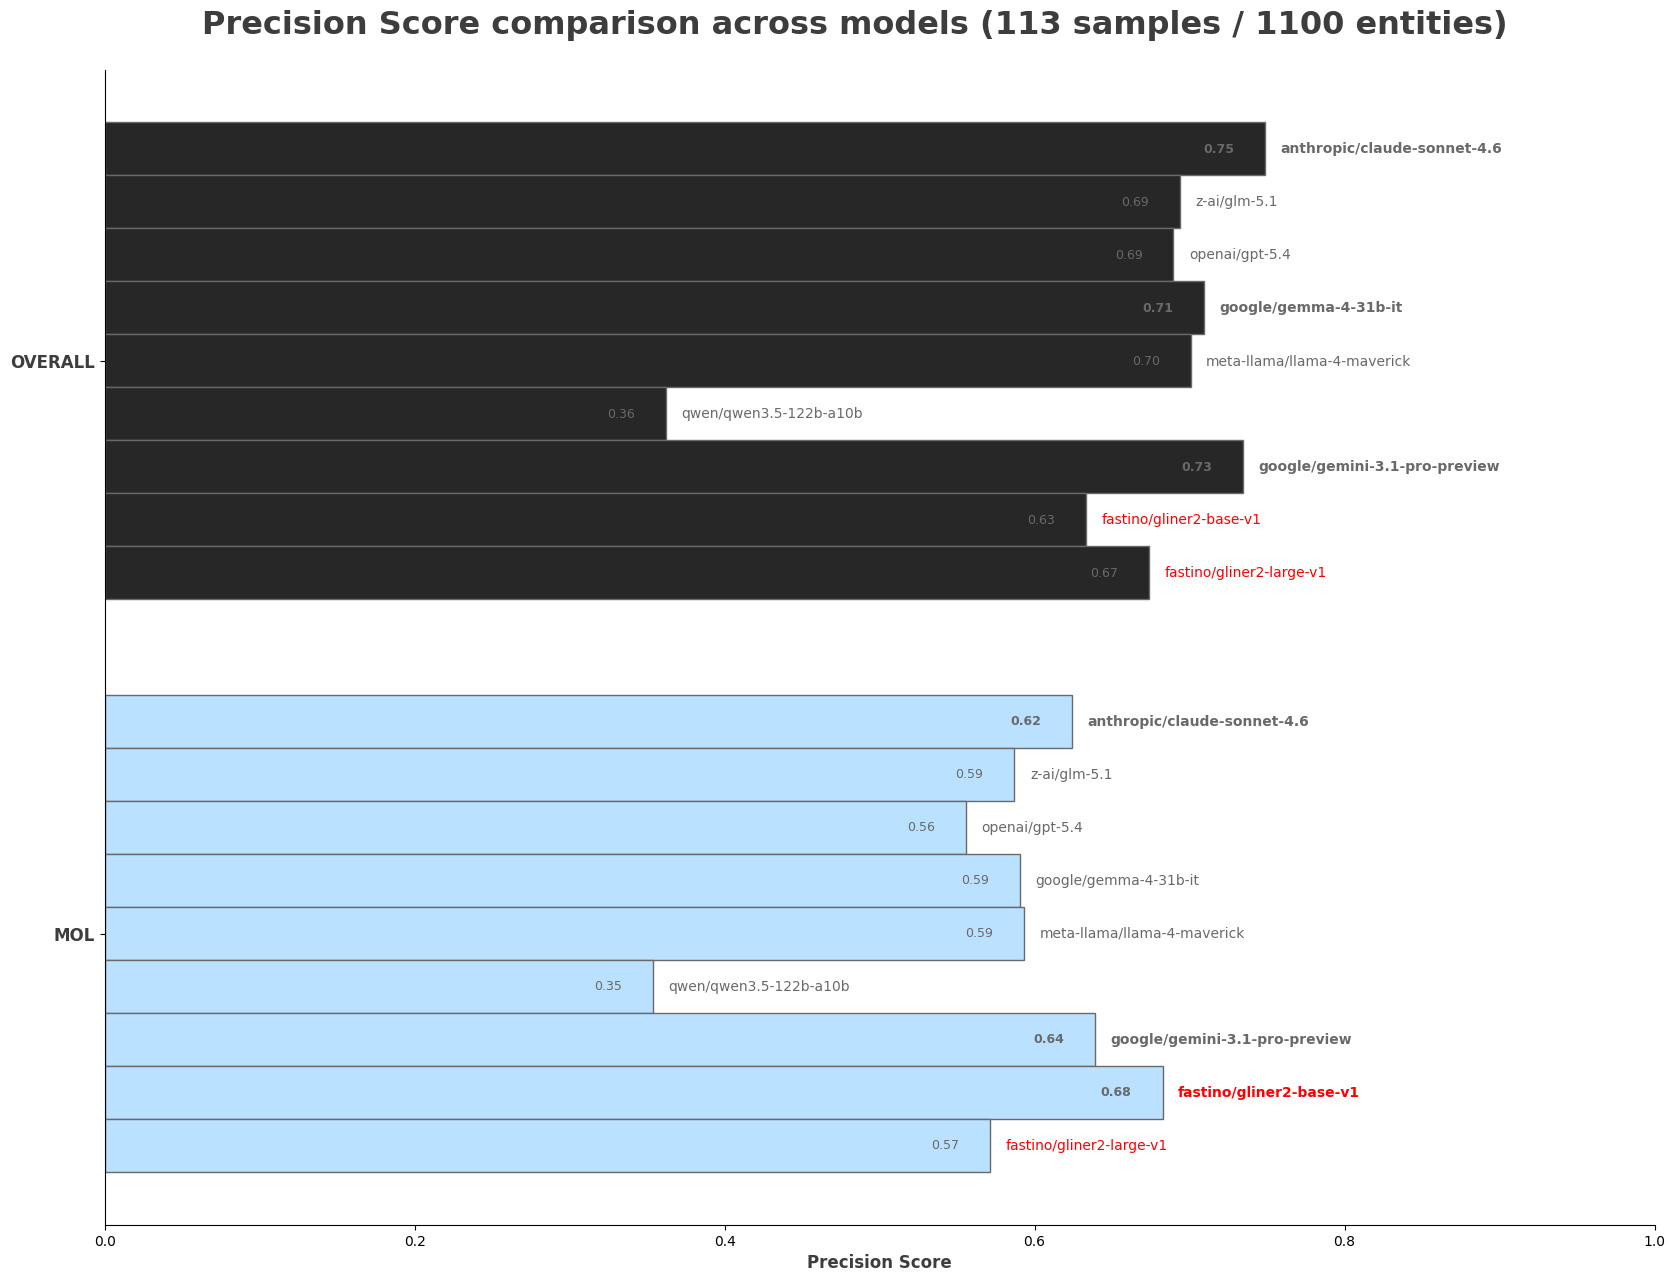

In [147]:
plot_score(
    df=eval_df,
    framework=framework,
    metric=metric,
    categories=categories,
    models=models,
    top_k=3,
)